# Operational Framework for ABM Methodological Choices: Reproduction Notebook

**Companion notebook to:** *Building Standards for Agent-Based Models* and Supplementary Material S1 (*Operational Decision Framework with Case Demonstration*)

**Authors:** Thiago Joel Angrizanes Rossi, Murilo Mazzotti Silvestrini, Cecília Klapka, Flávia Mori Sarti
**DOI (Zenodo):** [to be assigned upon archiving]
**Code repository:** https://github.com/muriloms/paper-scoping-review-protocol
**Date:** [submission date]

---

## What this notebook is — and what it is not

This notebook is a **reproduction artifact**. Its purpose is twofold:

1. To reproduce the empirical analyses reported in the main manuscript, from the publicly released scoping review dataset.

2. To document how the operational framework presented in Supplementary Material S1 was applied to the two case studies (de Ruig et al., 2023; Zhang et al., 2024). Each application is shown as a sequence of attribute classifications, rule lookups, and resulting recommendations.

**This notebook is not an automated decision tool.** The framework operationalized in Supplementary Material S1 is a structured protocol for human reasoning, not an algorithm. Applying it to any specific model requires expert judgment at each step — most importantly in classifying the model's objective, the richness and quality of its data, the presence of structural constraints among parameters, and the computational characteristics of the simulation. What the code can do is to make the framework's recommendations transparent and reproducible *conditional on a given classification of the model's attributes*.

In the scoping review reported in the main manuscript, attribute classification was performed by independent coders followed by consensus discussion, with inter-rater agreement. The same process is the appropriate one for any researcher applying the framework to their own work.

## How to use this notebook

The notebook is organized in five sections. Sections 1 through 3 reproduce empirical analyses from the manuscript. Sections 4 and 5 document the application of the framework to the two case studies. The final section restates the limits of the framework and the appropriate use of the notebook.

Execute cells in order. All data needed are bundled with the notebook in the `data/` directory.


---
## 0. Setup

Load libraries and the public dataset of coded scoping review studies.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import sys
import os
import warnings
warnings.filterwarnings("ignore")

# Display options
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["font.family"] = "DejaVu Sans"

print("Libraries loaded.")

Libraries loaded.


In [22]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

# Load the coded dataset (one row per included study).
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "ScopingReviewAbm.csv")
df = pd.read_csv(DATA_PATH)

# Standardize column names used downstream
df = df.rename(columns={
    "Publication Year": "year",
    "Model Objective (optional)": "objective_raw",
    "Data Source (Parameterization)": "data_source_raw",
    "Sensitivity Analysis": "sa_raw",
    "Publication Title": "venue",
})

df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

print(f"Loaded {len(df)} included studies.")
print(f"Year range: {df['year'].min()} to {df['year'].max()}")
df[["Key", "year", "Author", "Title", "objective_raw", "data_source_raw", "sa_raw"]].head(3)

Loaded 348 included studies.
Year range: 2015 to 2025


,Key,year,Author,Title,objective_raw,data_source_raw,sa_raw
0,9D8JUUVQ,2024,E. Alvarez; J. G. Brida; N. Garrido,Crowding Types and Price Dynamics in Tourism Destinations Choice,"Exploratory, Decision Support / Policy Evaluation",Theoretical (literature),"NA, Exploratory / Scenario-based"
1,GG8VFJQX,2025,L. M. Pantoja-Rojas; M. A. Alzate-Monroy; V. H. Medina-Garcãa; L. G. Moreno-Sandoval,Cognitive Agent-Based Modeling to Optimize Complex Project Management Under Uncertainty,Exploratory,Theoretical (literature),"Global (Variance-based), Global (Screening)"
2,9CLYR4IQ,2025,"S-Alotibi, Y.S.",A socio-technical agent-based simulation model for predicting smart agriculture adoption dynamics,"Predictive, Decision Support / Policy Evaluation","Theoretical (literature), Empirical (macro)","Exploratory / Scenario-based, Regression / Statistical Inference"


---
## 1. Preprocessing: from multi-label codings to canonical categories

Many studies were coded with multiple values per dimension (for example, a model with both *Predictive* and *Decision Support* objectives, or with both *Local OAT* and *Scenario-based* sensitivity analysis). For the alignment analysis we need a single canonical category per dimension per study. The rule used in the manuscript is:

- **Objective:** the most demanding category from an evidential standpoint is taken as dominant. The ordering is Decision Support > Predictive > Explanatory > Exploratory > Theoretical/Illustrative > Descriptive. *Decision Support / Policy Evaluation* is dominant whenever present.
- **Data source:** the richest category is taken as dominant. *Hybrid* dominates *Empirical (micro)* dominates *Empirical (macro)* dominates *Synthetic* dominates *Expert-based* dominates *Theoretical (literature)*.
- **Sensitivity analysis:** the most rigorous global method is taken as dominant. Among global methods, the ordering is Variance-based > Metamodeling > Screening > Regression. Local OAT and Exploratory/Scenario-based are taken as "weak SA" when no global method is present in the codings.

This canonicalization is itself a judgment-laden step. It was performed during the scoping review and documented in the codebook (Supplementary Material S4).

In [23]:
# Dominance orderings (highest priority first)
OBJ_ORDER = [
    "Decision Support / Policy Evaluation",
    "Predictive",
    "Explanatory",
    "Exploratory",
    "Theoretical / Illustrative",
    "Descriptive / Phenomena-based",
]
DS_ORDER = [
    "Hybrid",
    "Empirical (micro)",
    "Empirical (macro)",
    "Synthetic (machine learning, AI, other)",
    "Expert-based (qualitative, interview, participatory)",
    "Theoretical (literature)",
]
SA_ORDER = [
    "Global (Variance-based)",
    "Metamodeling / Surrogate",
    "Global (Screening)",
    "Regression / Statistical Inference",
    "Local (OAT/OFAT)",
    "Exploratory / Scenario-based",
    "NA",
]

def dominant(raw, order):
    """Return the highest-priority category present in a comma-separated multi-label string."""
    if pd.isna(raw) or raw.strip() == "":
        return None
    raw_norm = raw.replace('"', '')
    for category in order:
        if category in raw_norm:
            return category
    return None

df["objective"] = df["objective_raw"].apply(lambda x: dominant(x, OBJ_ORDER))
df["data_source"] = df["data_source_raw"].apply(lambda x: dominant(x, DS_ORDER))
df["sa"] = df["sa_raw"].apply(lambda x: dominant(x, SA_ORDER))
df["sa"] = df["sa"].fillna("NA")

# Drop rows missing
df_analysis = df.dropna(subset=["data_source"]).copy()
print(f"Studies retained after canonicalization: {len(df_analysis)} of {len(df)}")
print()
print("Objective distribution:")
print(df_analysis["objective"].value_counts())
print()
print("Data source distribution:")
print(df_analysis["data_source"].value_counts())
print()
print("Sensitivity analysis distribution:")
print(df_analysis["sa"].value_counts())

Studies retained after canonicalization: 304 of 348

Objective distribution:
objective
Decision Support / Policy Evaluation    162
Explanatory                              69
Theoretical / Illustrative               29
Exploratory                              20
Predictive                               14
Descriptive / Phenomena-based            10
Name: count, dtype: int64

Data source distribution:
data_source
Hybrid                                                  151
Empirical (micro)                                        67
Theoretical (literature)                                 52
Empirical (macro)                                        21
Synthetic (machine learning, AI, other)                  11
Expert-based (qualitative, interview, participatory)      2
Name: count, dtype: int64

Sensitivity analysis distribution:
sa
Exploratory / Scenario-based          106
Regression / Statistical Inference     67
Local (OAT/OFAT)                       66
Global (Variance-based)          

---
## 2. Methodological Alignment Index (reproduces Section 4.5)

The Methodological Alignment Index (MAI) is the proportion of studies whose combination of (objective, data source, sensitivity analysis) belongs to the set of pathways recommended by the framework. We define the recommended set following the rules in Supplementary Material S1, Section 2.1.

### 2.1. Defining the recommended set

The recommended combinations are derived from Rules 1 through 6 of the framework (baseline rules conditional on model objective). The override rules (7, 8, 9) cannot be applied at the population level without per-study judgment about structural constraints and computational cost, so the MAI uses the baseline recommendations only. This is a *conservative* definition: studies that adopt an override-justified pathway will appear as misaligned in this analysis unless the override rationale is explicit. The implications are discussed in Section 4.5 of the main manuscript.

In [24]:
# Recommended (objective, sa) combinations per Rule 1-6 of the framework.
# Note: data source is part of the recommendation but is conditioned on availability,
# which is not uniformly observable from the study metadata. We therefore evaluate
# alignment on the (objective, sa) projection, which is what Section 4.5 reports.

RECOMMENDED_SA_BY_OBJECTIVE = {
    "Decision Support / Policy Evaluation": {
        "Global (Variance-based)",
        "Metamodeling / Surrogate",
        "Global (Screening)",  # acceptable as part of two-stage
    },
    "Predictive": {
        "Global (Variance-based)",
        "Metamodeling / Surrogate",
        "Global (Screening)",
    },
    "Explanatory": {
        "Global (Screening)",
        "Global (Variance-based)",
        "Exploratory / Scenario-based",  # acceptable for mechanism comparison
    },
    "Exploratory": {
        "Exploratory / Scenario-based",
        "Global (Screening)",
        "Local (OAT/OFAT)",  # acceptable for exploratory diagnostics
    },
    "Theoretical / Illustrative": {
        "Local (OAT/OFAT)",
        "Exploratory / Scenario-based",
        "NA",  # may be acceptable for purely theoretical models
    },
    "Descriptive / Phenomena-based": {
        "Exploratory / Scenario-based",
        "Regression / Statistical Inference",
        "NA",  # may be acceptable for purely descriptive models
    },
}

def is_aligned(row):
    rec = RECOMMENDED_SA_BY_OBJECTIVE.get(row["objective"], set())
    return row["sa"] in rec

df_analysis["aligned"] = df_analysis.apply(is_aligned, axis=1)

# Overall MAI
overall_mai = df_analysis["aligned"].mean()
print(f"Overall MAI: {overall_mai:.3f}  (n = {len(df_analysis)})")

Overall MAI: 0.329  (n = 304)


### 2.2. MAI stratified by model objective

The framework's central empirical claim is that misalignment is concentrated in the categories with the highest evidential burden — decision-support and predictive models. Stratifying the MAI by objective tests this directly.

In [25]:
mai_by_obj = (df_analysis
    .groupby("objective")
    .agg(n=("aligned", "size"), aligned_n=("aligned", "sum"), mai=("aligned", "mean"))
    .reindex(OBJ_ORDER)
    .dropna()
)
mai_by_obj["mai"] = mai_by_obj["mai"].round(3)
print(mai_by_obj)

                                        n  aligned_n    mai
objective                                                  
Decision Support / Policy Evaluation  162         30  0.185
Predictive                             14          1  0.071
Explanatory                            69         31  0.449
Exploratory                            20         13  0.650
Theoretical / Illustrative             29         18  0.621
Descriptive / Phenomena-based          10          7  0.700


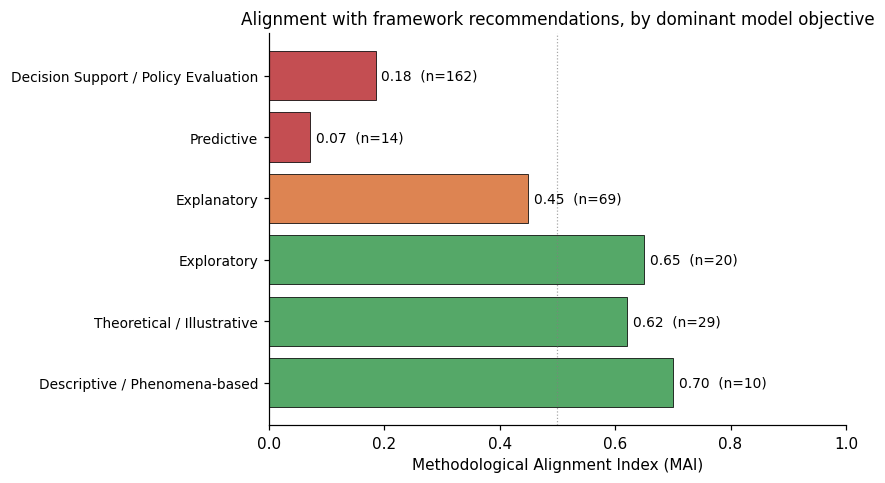

In [26]:
# Figure: MAI by objective (reproduces Figure XX of the main manuscript)
fig, ax = plt.subplots(figsize=(8, 4.5))

categories = mai_by_obj.index.tolist()
mai_vals = mai_by_obj["mai"].values
n_vals = mai_by_obj["n"].values

colors = ["#c44e52" if v < 0.35 else "#dd8452" if v < 0.55 else "#55a868" for v in mai_vals]
bars = ax.barh(range(len(categories)), mai_vals, color=colors, edgecolor="black", linewidth=0.5)

for i, (v, n) in enumerate(zip(mai_vals, n_vals)):
    ax.text(v + 0.01, i, f"{v:.2f}  (n={n})", va="center", fontsize=9)

ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories, fontsize=9)
ax.set_xlabel("Methodological Alignment Index (MAI)", fontsize=10)
ax.set_xlim(0, 1)
ax.set_title("Alignment with framework recommendations, by dominant model objective", fontsize=11)
ax.axvline(0.5, color="grey", linestyle=":", linewidth=0.8, alpha=0.7)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figure_mai_by_objective.png", bbox_inches="tight")
plt.show()

### 2.3. Statistical test of independence

We test the null hypothesis that observed (objective, sa) combinations are independent of the framework's recommendations. Under H₀, the rate of aligned combinations should not differ from chance given the marginal distributions. Under H₁, alignment is structurally related to objective category, which would be expected if the field implicitly recognizes the framework's logic in some cases (exploratory and theoretical) but not in others (decision-support and predictive).

In [27]:
from scipy.stats import chi2_contingency

# Contingency: alignment (yes/no) × objective
ct = pd.crosstab(df_analysis["objective"], df_analysis["aligned"])
ct = ct.reindex(OBJ_ORDER).dropna()
print("Contingency table (objective × aligned):")
print(ct)
print()

chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4g}")

# Effect size (Cramer's V)
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"Cramer's V: {cramers_v:.3f}")

Contingency table (objective × aligned):
aligned                               False  True 
objective                                         
Decision Support / Policy Evaluation    132     30
Predictive                               13      1
Explanatory                              38     31
Exploratory                               7     13
Theoretical / Illustrative               11     18
Descriptive / Phenomena-based             3      7

Chi-square statistic: 50.658
Degrees of freedom: 5
p-value: 1.016e-09
Cramer's V: 0.408


### 2.4. Interpretation note

The MAI quantifies *baseline* alignment without invoking the override rules of the framework (structural constraints, computational cost, very high dimensionality). Studies that adopt local SA in response to a high computational cost — a legitimate response under Rule 8 — will appear as misaligned in this analysis. The framework therefore does not interpret a low MAI as evidence that the studies are methodologically poor; it interprets a low MAI as evidence that *the methodological choice was not declared with reference to a framework-recognized override*. The remedy is documentation, not necessarily a change of method. This distinction is essential and is made explicit in the manuscript Discussion.

---
## 3. Temporal trends (reproduces Section 4.6)

The corpus spans 2015 to 2025. To address Reviewer 4's observation that aggregate analysis may obscure temporal heterogeneity, we stratify the alignment analysis in four periods and inspect whether the misalignment pattern has changed over time.

In [28]:
# Period bins
def assign_period(y):
    if pd.isna(y):
        return None
    if y <= 2017: return "2015-2017"
    if y <= 2020: return "2018-2020"
    if y <= 2023: return "2021-2023"
    return "2024-2025"

df_analysis["period"] = df_analysis["year"].apply(assign_period)
PERIOD_ORDER = ["2015-2017", "2018-2020", "2021-2023", "2024-2025"]

mai_by_period = (df_analysis
    .groupby("period")
    .agg(n=("aligned", "size"), mai=("aligned", "mean"))
    .reindex(PERIOD_ORDER)
    .dropna()
)
mai_by_period["mai"] = mai_by_period["mai"].round(3)
print("Overall MAI by period:")
print(mai_by_period)

Overall MAI by period:
            n    mai
period              
2015-2017  58  0.431
2018-2020  72  0.250
2021-2023  85  0.329
2024-2025  89  0.326


In [29]:
n_sem_ano = df_analysis["period"].isna().sum()
print(f"Estudos sem ano válido (excluídos da análise temporal): {n_sem_ano}")
print(f"Base da análise temporal: {len(df_analysis) - n_sem_ano} de {len(df_analysis)}")

Estudos sem ano válido (excluídos da análise temporal): 0
Base da análise temporal: 304 de 304


In [30]:
# MAI by period and objective (the policy-relevant projection)
focal_objectives = ["Decision Support / Policy Evaluation", "Predictive",
                    "Explanatory", "Exploratory"]

mai_period_obj = (df_analysis[df_analysis["objective"].isin(focal_objectives)]
    .groupby(["period", "objective"])
    .agg(n=("aligned", "size"), mai=("aligned", "mean"))
    .reset_index()
)
mai_period_obj_wide = mai_period_obj.pivot(index="period", columns="objective", values="mai").reindex(PERIOD_ORDER)
print("\nMAI by period × objective:")
print(mai_period_obj_wide.round(3))


MAI by period × objective:
objective  Decision Support / Policy Evaluation  Explanatory  Exploratory  Predictive
period                                                                               
2015-2017                                 0.174        0.733        0.500         0.0
2018-2020                                 0.031        0.316        0.833         0.0
2021-2023                                 0.250        0.368        0.500         0.5
2024-2025                                 0.218        0.438        0.625         0.0


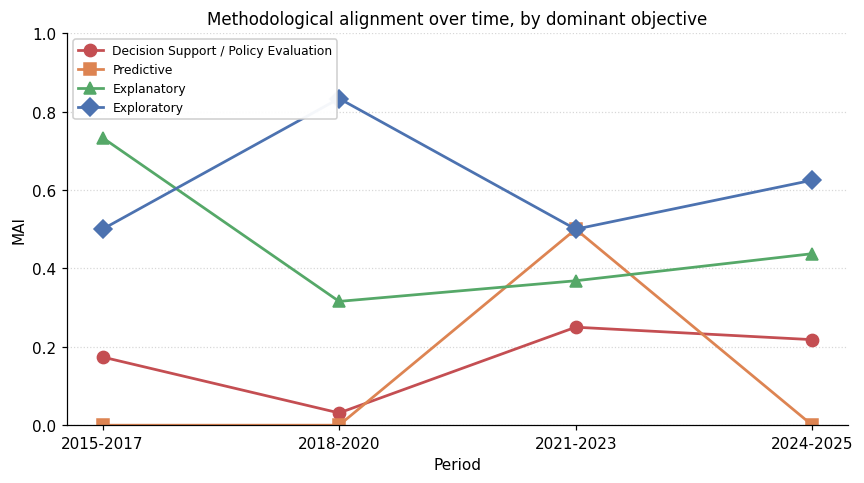

In [31]:
# Figure: temporal trends by objective
fig, ax = plt.subplots(figsize=(8, 4.5))

markers = {"Decision Support / Policy Evaluation": "o",
           "Predictive": "s", "Explanatory": "^", "Exploratory": "D"}
colors_obj = {"Decision Support / Policy Evaluation": "#c44e52",
              "Predictive": "#dd8452", "Explanatory": "#55a868",
              "Exploratory": "#4c72b0"}

for obj in focal_objectives:
    if obj in mai_period_obj_wide.columns:
        vals = mai_period_obj_wide[obj].dropna()
        ax.plot(vals.index, vals.values, marker=markers[obj], color=colors_obj[obj],
                linewidth=1.8, markersize=8, label=obj)

ax.set_ylabel("MAI", fontsize=10)
ax.set_xlabel("Period", fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("Methodological alignment over time, by dominant objective", fontsize=11)
ax.legend(fontsize=8, loc="upper left", framealpha=0.95)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figure_mai_temporal.png", bbox_inches="tight")
plt.show()

### 3.1. Trend in AI/ML calibration

Reviewer 4 hypothesized that AI-based calibration has become more prevalent in recent years. We test this by identifying studies with synthetic (machine learning, AI, other) data sources and tracking their proportion by period.

In [32]:
# AI/ML calibration uses the Synthetic data source category
df["uses_ml"] = df["data_source_raw"].fillna("").str.contains("Synthetic", regex=False)
df["period"] = df["year"].apply(assign_period)

ml_trend = (df.dropna(subset=["period"])
    .groupby("period")
    .agg(n=("uses_ml", "size"), n_ml=("uses_ml", "sum"))
    .reindex(PERIOD_ORDER)
)
ml_trend["proportion"] = (ml_trend["n_ml"] / ml_trend["n"]).round(3)
print(ml_trend)

             n  n_ml  proportion
period                          
2015-2017   64     1       0.016
2018-2020   78     7       0.090
2021-2023  100     9       0.090
2024-2025  106     7       0.066


In [33]:
# Cochran-Armitage trend test (using a chi-square approximation)
from scipy.stats import chi2 as chi2_dist

# Encode periods ordinally (1, 2, 3, 4)
period_codes = {p: i+1 for i, p in enumerate(PERIOD_ORDER)}
df["period_code"] = df["period"].map(period_codes)

valid = df.dropna(subset=["period_code"]).copy()
x = valid["period_code"].values
y = valid["uses_ml"].astype(int).values

# Cochran-Armitage statistic
n = len(x)
xbar = x.mean()
ybar = y.mean()
num = np.sum((x - xbar) * (y - ybar))
den_x = np.sum((x - xbar) ** 2)
T = num**2 / (den_x * ybar * (1 - ybar))
p_trend = 1 - chi2_dist.cdf(T, df=1)
print(f"Cochran-Armitage trend statistic: T = {T:.3f}")
print(f"p-value: {p_trend:.4g}")
print()
if p_trend < 0.05:
    print("Significant monotonic trend in the use of AI/ML for calibration over the period.")
else:
    print("No significant monotonic trend detected. The proportion of AI/ML calibration")
    print("studies varies but is not statistically distinguishable from constant over the period.")

Cochran-Armitage trend statistic: T = 0.908
p-value: 0.3407

No significant monotonic trend detected. The proportion of AI/ML calibration
studies varies but is not statistically distinguishable from constant over the period.


---
## 4. Case demonstration: de Ruig et al. (2023)

This section documents how the framework's protocol (Supplementary Material S1, Section 2.2) was applied retrospectively to de Ruig, Haer, de Moel, Orton, Botzen, & Aerts (2023), *An agent-based model for evaluating reforms of the National Flood Insurance Program: A benchmarked model applied to Jamaica Bay, NYC*, Risk Analysis 43(2), 405–422. DOI: 10.1111/risa.13905.

The documentation has four parts. First, we extract the relevant attributes of the study from the publication and from the scoping review codings. Second, we apply each step of the protocol to those attributes. Third, we look up the framework's recommended pathway given the attributes. Fourth, we compare recommended and adopted pathways side by side.

**The classification of attributes in the next cell required expert judgment.** It was performed independently by the coders of the scoping review and reconciled by consensus. The values shown here are the final consensus classifications. A different research team applying the framework to the same paper might arrive at slightly different classifications, particularly on Step 3 (structural constraints). The framework makes these judgment points visible rather than hiding them.

In [34]:
# Step 1-5: Attribute classification (documented from the publication, not automated)

case_deruig = {
    "citation": "de Ruig et al. (2023), Risk Analysis 43(2), 405-422. DOI: 10.1111/risa.13905",
    "step_1_objective": {
        "value": "Decision Support / Policy Evaluation",
        "evidence": ("The authors explicitly state that the model is built to support "
                     "policymakers in making adaptation decisions and to evaluate the "
                     "effectiveness of proposed reforms to the NFIP."),
    },
    "step_2_data_availability": {
        "value": "rich micro-level",
        "evidence": ("Parameterization draws on (a) a household survey of NYC residents "
                     "for behavioral parameters, (b) FEMA depth-damage curves, and (c) "
                     "building-level GIS data. The benchmarking against survey data is "
                     "a defining methodological feature of the study."),
    },
    "step_3_structural_constraints": {
        "value": "present but not declared",
        "evidence": ("Behavioral parameters (perceived flood risk, willingness to invest) "
                     "are theoretically correlated; insurance and coverage decisions are "
                     "linked through household budget constraints. The publication does "
                     "not document these dependencies as constraints on the SA sampling."),
    },
    "step_4_computational_cost": {
        "value": "moderate to high (estimated)",
        "evidence": ("Per-run cost not reported. The model couples a behavioral submodel "
                     "with flood inundation and economic decision components, simulated "
                     "over a multi-decade horizon for the homeowner population of "
                     "Jamaica Bay. Direct Sobol would require substantially more "
                     "simulation budget than the reported OAT analysis."),
    },
    "step_5_dimensionality": {
        "value": "moderate (10-50)",
        "evidence": ("The free parameter set comprises behavioral parameters (from the "
                     "survey), economic parameters (insurance market), and policy "
                     "parameters (reform scenarios). Order of magnitude: tens, not hundreds."),
    },
    "adopted_data_source": "Empirical (micro)",
    "adopted_sa": "Local (OAT/OFAT)",
    "adopted_reporting": "ODD-style description in the appendix",
}

print(f"Case: {case_deruig['citation']}")
print()
for step in ["step_1_objective", "step_2_data_availability", "step_3_structural_constraints",
             "step_4_computational_cost", "step_5_dimensionality"]:
    info = case_deruig[step]
    print(f"--- {step.replace('_', ' ').title()} ---")
    print(f"  Classified value: {info['value']}")
    print(f"  Evidence: {info['evidence']}")
    print()

Case: de Ruig et al. (2023), Risk Analysis 43(2), 405-422. DOI: 10.1111/risa.13905

--- Step 1 Objective ---
  Classified value: Decision Support / Policy Evaluation
  Evidence: The authors explicitly state that the model is built to support policymakers in making adaptation decisions and to evaluate the effectiveness of proposed reforms to the NFIP.

--- Step 2 Data Availability ---
  Classified value: rich micro-level
  Evidence: Parameterization draws on (a) a household survey of NYC residents for behavioral parameters, (b) FEMA depth-damage curves, and (c) building-level GIS data. The benchmarking against survey data is a defining methodological feature of the study.

--- Step 3 Structural Constraints ---
  Classified value: present but not declared
  Evidence: Behavioral parameters (perceived flood risk, willingness to invest) are theoretically correlated; insurance and coverage decisions are linked through household budget constraints. The publication does not document these depe

### 4.1. Step 6 — Applying the baseline rule

Given the Step 1 classification (Decision Support / Policy Evaluation) and Step 2 classification (rich micro-level data), Rule 1 of the framework applies.

In [35]:
# Rule 1 lookup (matches Supplementary Material S1)
RULE_1 = {
    "name": "Rule 1 — Decision-support model with rich micro-level data",
    "condition": ("model_objective = decision-support AND "
                  "data_availability = rich_micro_level"),
    "recommended_data_source": "Hybrid (empirical + theoretical priors)",
    "recommended_parameterization": "Direct calibration with structural priors",
    "recommended_sa": ("Morris screening + Global variance-based (Sobol). "
                       "Metamodeling if per-run cost is prohibitive (Rule 8 override)."),
    "recommended_documentation": "ODD+D + TRACE",
}

print(f"Applicable rule: {RULE_1['name']}")
print(f"Condition: {RULE_1['condition']}")
print()
print("Framework recommendations:")
print(f"  Data source: {RULE_1['recommended_data_source']}")
print(f"  Parameterization: {RULE_1['recommended_parameterization']}")
print(f"  Sensitivity analysis: {RULE_1['recommended_sa']}")
print(f"  Documentation: {RULE_1['recommended_documentation']}")

Applicable rule: Rule 1 — Decision-support model with rich micro-level data
Condition: model_objective = decision-support AND data_availability = rich_micro_level

Framework recommendations:
  Data source: Hybrid (empirical + theoretical priors)
  Parameterization: Direct calibration with structural priors
  Sensitivity analysis: Morris screening + Global variance-based (Sobol). Metamodeling if per-run cost is prohibitive (Rule 8 override).
  Documentation: ODD+D + TRACE


### 4.2. Steps 7-9 — Override rules

Rule 7 (structural constraints) and Rule 8 (computational cost) are candidates for application given Steps 3 and 4 above. Rule 9 (very high dimensionality) is not applicable.

In [36]:
# Override evaluation
overrides = []

if "present" in case_deruig["step_3_structural_constraints"]["value"]:
    overrides.append({
        "rule": "Rule 7 (structural constraints)",
        "applicable": True,
        "if_applied": ("Modify the SA sampling strategy to respect parameter "
                       "dependencies: constrained LHS, generalized Sobol indices, "
                       "or copula-based sampling. Document the dependencies explicitly."),
        "in_practice": ("Not applied in the original study. Dependencies were "
                        "not formally identified."),
    })

if "high" in case_deruig["step_4_computational_cost"]["value"]:
    overrides.append({
        "rule": "Rule 8 (prohibitive computational cost)",
        "applicable": "candidate (estimated cost)",
        "if_applied": ("Use metamodeling (Gaussian process or polynomial chaos) "
                       "to enable global SA at reduced marginal cost. Validate "
                       "the surrogate's accuracy before trusting SA output."),
        "in_practice": ("OAT was used. This is one possible response to high "
                        "cost, but it has weaker epistemic standing than a "
                        "properly validated surrogate-based global SA."),
    })

for ov in overrides:
    print(f"--- {ov['rule']} ---")
    print(f"  Applicable: {ov['applicable']}")
    print(f"  If applied: {ov['if_applied']}")
    print(f"  In practice: {ov['in_practice']}")
    print()

--- Rule 7 (structural constraints) ---
  Applicable: True
  If applied: Modify the SA sampling strategy to respect parameter dependencies: constrained LHS, generalized Sobol indices, or copula-based sampling. Document the dependencies explicitly.
  In practice: Not applied in the original study. Dependencies were not formally identified.

--- Rule 8 (prohibitive computational cost) ---
  Applicable: candidate (estimated cost)
  If applied: Use metamodeling (Gaussian process or polynomial chaos) to enable global SA at reduced marginal cost. Validate the surrogate's accuracy before trusting SA output.
  In practice: OAT was used. This is one possible response to high cost, but it has weaker epistemic standing than a properly validated surrogate-based global SA.



### 4.3. Step 10 — Comparing recommended and adopted pathways

Table reproducing Table S1.3 of Supplementary Material S1.

In [37]:
pathway_comparison = pd.DataFrame([
    {"Decision point": "Model objective classification",
     "Framework recommendation": "Decision-support",
     "de Ruig et al. (2023)": "Decision-support",
     "Status": "ALIGNED"},
    {"Decision point": "Data source",
     "Framework recommendation": "Hybrid (empirical micro + theoretical priors)",
     "de Ruig et al. (2023)": "Empirical (micro) with theoretical structure",
     "Status": "ALIGNED"},
    {"Decision point": "Parameterization strategy",
     "Framework recommendation": "Direct calibration with structural priors",
     "de Ruig et al. (2023)": "Benchmarking against survey data",
     "Status": "ALIGNED"},
    {"Decision point": "Structural constraints handling",
     "Framework recommendation": "Identify dependencies; use constrained sampling",
     "de Ruig et al. (2023)": "Not explicitly addressed",
     "Status": "DIVERGENT"},
    {"Decision point": "Sensitivity analysis method",
     "Framework recommendation": "Morris + Sobol (Rule 1) or metamodel-assisted (Rule 8)",
     "de Ruig et al. (2023)": "Local OAT",
     "Status": "DIVERGENT"},
    {"Decision point": "Reporting of interactions",
     "Framework recommendation": "First-order and total-order indices reported",
     "de Ruig et al. (2023)": "Not reported (incompatible with OAT)",
     "Status": "DIVERGENT"},
    {"Decision point": "Reporting protocol",
     "Framework recommendation": "ODD+D + TRACE",
     "de Ruig et al. (2023)": "ODD-style description",
     "Status": "ALIGNED"},
])

# Render as styled table
def color_status(val):
    if val == "ALIGNED":
        return "background-color: #d4edda; color: #155724"
    elif val == "DIVERGENT":
        return "background-color: #fff3cd; color: #856404"
    return ""

pathway_comparison.style.map(color_status, subset=["Status"])

,Decision point,Framework recommendation,de Ruig et al. (2023),Status
0,Model objective classification,Decision-support,Decision-support,ALIGNED
1,Data source,Hybrid (empirical micro + theoretical priors),Empirical (micro) with theoretical structure,ALIGNED
2,Parameterization strategy,Direct calibration with structural priors,Benchmarking against survey data,ALIGNED
3,Structural constraints handling,Identify dependencies; use constrained sampling,Not explicitly addressed,DIVERGENT
4,Sensitivity analysis method,Morris + Sobol (Rule 1) or metamodel-assisted (Rule 8),Local OAT,DIVERGENT
5,Reporting of interactions,First-order and total-order indices reported,Not reported (incompatible with OAT),DIVERGENT
6,Reporting protocol,ODD+D + TRACE,ODD-style description,ALIGNED


### 4.4. Substantive interpretation

Three of the seven decision points show divergence between the framework's recommendations and the choices made in the original study, with one source (the choice of SA method) propagating into a second consequence (the inability to report interaction effects). The remaining substantive divergences are therefore two: the absence of explicit treatment of structural constraints, and the choice of local rather than global SA.

The framework's interpretation of these divergences is not that the study is unsound. The authors made a defensible choice given the constraints they faced, and their benchmarking of the behavioral component against empirical data is itself a substantive methodological contribution. The framework's interpretation is that the divergences reflect implicit, undocumented decisions where the framework would have required explicit, documented ones. Had the framework been available at the design stage, the choice between OAT (Rule 1 baseline departure) and metamodel-assisted global SA (Rule 8 override) would have been framed as an explicit trade-off, with the rationale documented in the publication. The function of the framework is prospective guidance, not retrospective critique.

Section 3.5 of Supplementary Material S1 develops this interpretation in detail, including a discussion of how interaction effects between behavioral and economic parameters could plausibly affect the policy ranking of the three NFIP reforms under climate change scenarios.

---
## 5. Case demonstration: Zhang et al. (2024)

This section documents the application of the framework to the secondary case: Zhang, Yang, Abeshu, Li, Hung, Lin, & Leung (2024), *Exploring the food–energy–water nexus in coupled natural-human systems under climate change with a fully integrated agent-based modeling framework*, Journal of Hydrology 634, 131048. DOI: 10.1016/j.jhydrol.2024.131048.

The secondary case is presented in less detail because the structure of the analysis is the same as for the primary case. The pedagogical value lies in showing that methodological misalignment is not restricted to the use of OAT, but extends to a broader class of partial SA practices that fall short of the framework's recommendations.

In [38]:
case_zhang = {
    "citation": "Zhang et al. (2024), Journal of Hydrology 634, 131048. DOI: 10.1016/j.jhydrol.2024.131048",
    "step_1_objective": "Predictive + Decision Support / Policy Evaluation",
    "step_2_data_availability": "rich (hybrid hydrologic + behavioral)",
    "step_3_structural_constraints": ("present and substantial: coupled water-crop-energy "
                                       "dynamics imply parameter dependencies"),
    "step_4_computational_cost": "high (distributed hydrologic model coupled with ABM)",
    "step_5_dimensionality": "moderate to high",
    "applicable_rules": ["Rule 1 (decision-support, rich data)", "Rule 3 (predictive, rich data)",
                         "Rule 7 (constraints)", "Rule 8 (cost)"],
    "framework_recommendation": ("Metamodel-assisted Sobol indices over constrained sampling "
                                 "design (joint application of Rules 1+3 with Rules 7 and 8)"),
    "adopted_sa": "Exploratory / Scenario-based + Regression / Statistical Inference",
}

for k, v in case_zhang.items():
    if isinstance(v, list):
        print(f"{k}:")
        for item in v:
            print(f"  - {item}")
    else:
        print(f"{k}: {v}")
    print()

citation: Zhang et al. (2024), Journal of Hydrology 634, 131048. DOI: 10.1016/j.jhydrol.2024.131048

step_1_objective: Predictive + Decision Support / Policy Evaluation

step_2_data_availability: rich (hybrid hydrologic + behavioral)

step_3_structural_constraints: present and substantial: coupled water-crop-energy dynamics imply parameter dependencies

step_4_computational_cost: high (distributed hydrologic model coupled with ABM)

step_5_dimensionality: moderate to high

applicable_rules:
  - Rule 1 (decision-support, rich data)
  - Rule 3 (predictive, rich data)
  - Rule 7 (constraints)
  - Rule 8 (cost)

framework_recommendation: Metamodel-assisted Sobol indices over constrained sampling design (joint application of Rules 1+3 with Rules 7 and 8)

adopted_sa: Exploratory / Scenario-based + Regression / Statistical Inference



The Zhang et al. case is informative for two reasons.

First, it shows that scenario-based and regression-based SA, while substantially stronger than OAT, still fall short of what the framework recommends for predictive and decision-support models with rich data and coupled-system dynamics. Scenario-based analysis covers a discrete set of pre-specified configurations but cannot decompose the contribution of individual parameters to output variance, and is particularly limited when parameter interactions drive regime shifts under climate change, which is precisely the scenario the paper explores. Regression-based inference partially addresses decomposition but assumes additive functional forms that may not hold in coupled human-natural systems.

Second, the case demonstrates how Rules 7 and 8 jointly modify the baseline recommendation. The framework does not blindly demand Sobol indices regardless of feasibility; it specifies a chain of recommendations that adapts to the modeling exercise's constraints. For the Zhang et al. case, the joint application of Rules 1+3 (baseline) with Rule 7 (constraints) and Rule 8 (cost) yields a recommendation of metamodel-assisted Sobol indices over a constrained sampling design, which is computationally feasible and methodologically appropriate.

Taken together with the primary case, the secondary case supports the more general point made in Section 4.5 of the main manuscript: methodological misalignment in decision-support and predictive ABMs is not isolated, but a structural feature of the literature, manifesting differently across application domains. The framework is intended to make these conventions visible and revisable, not to enforce a single methodological recipe.

---
## 6. Framework checklist

This section provides the researcher-facing checklist from Supplementary Material S1, Section 2.3, implemented as a Python data structure.

### How to use

1. **Fill in the `my_model` dictionary below** with the values that correspond to your own model (or the model you are evaluating). Each key maps to a checklist item; acceptable values are shown as comments.
2. **Run the validation cell** to get a summary of complete, incomplete, and flagged items.
3. **Save the completed dictionary** as part of your supplementary materials when submitting your manuscript. A completed checklist that identifies divergences from the framework's recommendations — with documented justifications — satisfies the framework's documentation requirements more fully than a checklist with no divergences at all.

### What this checklist is not

This checklist does not automate the framework's application. Filling in the dictionary is itself a judgment act: deciding whether your data are "rich micro-level" or "rich aggregate", or whether structural constraints among your parameters are "present" or "absent", requires knowledge of the model that no code can substitute. The checklist's function is to make those judgments explicit and auditable, not to make them for you.

In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# RESEARCHER-FACING CHECKLIST
# Fill in the values for YOUR model (or the model you are evaluating).
# Accepted values are listed as comments beside each key.
# Leave a value as None if it genuinely does not apply; add a note string
# to the corresponding *_note key to document the reasoning.
# ─────────────────────────────────────────────────────────────────────────────

my_model = {

    # ── BLOCK A: Model objective and intended use ──────────────────────────

    # Was the primary model objective explicitly stated in the paper / design doc?
    # Accepted: "yes" | "no"
    "A1_objective_stated": None,

    # What is the primary objective?
    # Accepted: "decision-support" | "predictive" | "explanatory" |
    #           "exploratory" | "pedagogical/theoretical"
    "A2_objective_category": None,

    # If the model combines multiple objectives, which is DOMINANT for SA purposes?
    # Accepted: same values as A2, or "not applicable"
    "A3_dominant_objective": None,
    "A3_note": None,  # explain if not applicable or if tie-breaking was needed


    # ── BLOCK B: Data availability ─────────────────────────────────────────

    # Is an inventory of parameterization data sources provided?
    # Accepted: "yes" | "no"
    "B1_data_inventory": None,

    # Are all parameters mapped to a data source category?
    # Accepted: "yes" | "partial" | "no"
    # Categories: "empirical_micro" | "empirical_macro" | "theoretical_literature" |
    #             "expert_elicitation" | "synthetic_ai" | "hybrid"
    "B2_parameters_mapped": None,
    "B2_dominant_category": None,  # dominant data source category (see above)

    # Is the quality and coverage of each data source appraised?
    # Accepted: "yes" | "partial" | "no"
    "B3_data_quality_appraised": None,


    # ── BLOCK C: Structural constraints among parameters ───────────────────

    # Have consistency relations, accounting identities, conservation laws, and
    # empirically grounded correlations been identified?
    # Accepted: "yes" | "no" | "not_applicable"
    "C1_constraints_identified": None,
    "C1_note": None,  # list constraints if present

    # If constraints are present, does the SA sampling strategy respect them?
    # (constrained LHS, generalized Sobol, conditional Sobol, copula-based)
    # Accepted: "yes" | "no" | "not_applicable"
    "C2_sampling_respects_constraints": None,
    "C2_method_used": None,  # name the sampling method adopted

    # If no constraints apply, has this been explicitly documented?
    # Accepted: "yes" | "no" | "not_applicable"
    "C3_no_constraints_documented": None,


    # ── BLOCK D: Computational cost and dimensionality ────────────────────

    # Has the per-run cost been measured and reported?
    # Accepted: "yes" | "no"
    "D1_cost_measured": None,
    "D1_cost_estimate": None,  # e.g. "~3 min per run on [hardware]"

    # How many free parameters are subject to SA?
    # Accepted: integer, or a string such as "~30"
    "D2_n_free_parameters": None,

    # If cost or dimensionality triggers an override rule, is the rationale documented?
    # Accepted: "yes" | "no" | "not_applicable"
    "D3_override_documented": None,
    "D3_override_rule": None,  # "Rule 8" | "Rule 9" | "both" | "not_applicable"


    # ── BLOCK E: Sensitivity analysis ─────────────────────────────────────

    # Are the SA method(s) named and justified by reference to the framework?
    # Accepted: "yes" | "partial" | "no"
    "E1_sa_justified": None,
    "E1_sa_methods": None,  # list the method(s) actually used

    # If the chosen method departs from the framework's recommendation,
    # is the reason stated?
    # Accepted: "yes" | "no" | "not_applicable"
    "E2_departure_justified": None,
    "E2_departure_reason": None,  # e.g. "prohibitive per-run cost → Rule 8 override"

    # Are first-order and interaction effects distinguished in the SA output?
    # Accepted: "yes" | "no" | "not_applicable (local method)"
    "E3_interactions_reported": None,


    # ── BLOCK F: Documentation ─────────────────────────────────────────────

    # Which standardized reporting protocol was adopted?
    # Accepted: "ODD" | "ODD+D" | "TRACE" | "ODD+D+TRACE" | "none" | "other"
    "F1_reporting_protocol": None,
    "F1_note": None,

    # Is the model code available in a public repository with a persistent identifier?
    # Accepted: "yes" | "no"
    "F2_code_available": None,
    "F2_repository_url": None,

    # Is the completed framework checklist included as a supplementary material?
    # Accepted: "yes" | "no" | "in_progress"
    "F3_checklist_as_sm": None,
}

print("Checklist loaded. Edit the values above and run the validation cell below.")


Checklist loaded. Edit the values above and run the validation cell below.


In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# VALIDATION — run after filling in my_model above
# ─────────────────────────────────────────────────────────────────────────────

# Items that are structural (None = not started) vs. genuinely optional
REQUIRED = [
    "A1_objective_stated", "A2_objective_category",
    "B1_data_inventory", "B2_parameters_mapped", "B2_dominant_category",
    "C1_constraints_identified",
    "D1_cost_measured", "D2_n_free_parameters",
    "E1_sa_justified", "E1_sa_methods",
    "E3_interactions_reported",
    "F1_reporting_protocol", "F2_code_available",
]

CONDITIONAL = {
    "C2_sampling_respects_constraints": (
        "C1_constraints_identified", "yes",
        "Required when C1 = 'yes' (structural constraints present)"),
    "E2_departure_justified": (
        "E1_sa_justified", "partial",
        "Required when E1 = 'partial' (SA partially justified)"),
    "D3_override_documented": (
        "D1_cost_measured", "yes",
        "Required when override rules (8 or 9) may apply"),
}

# Framework compliance checks (alignment with rules in SM S1 Section 2.1)
ALIGNMENT_CHECKS = []

obj = my_model.get("A2_objective_category")
sa  = my_model.get("E1_sa_methods")

if obj and sa:
    decision_support_objectives = {"decision-support", "predictive"}
    weak_sa_methods = {"local oat", "oat", "one-at-a-time", "scenario-based",
                       "exploratory", "regression"}
    global_sa_methods = {"sobol", "variance-based", "morris", "screening",
                         "metamodel", "surrogate", "gaussian process"}

    obj_norm = obj.lower()
    sa_norm  = sa.lower() if isinstance(sa, str) else ""

    has_global = any(g in sa_norm for g in global_sa_methods)
    has_weak   = any(w in sa_norm for w in weak_sa_methods)

    if any(d in obj_norm for d in decision_support_objectives):
        if not has_global:
            ALIGNMENT_CHECKS.append(
                ("WARNING",
                 f"Objective '{obj}' + SA '{sa}': framework recommends global SA "
                 f"(Rules 1 or 3). If a departure from this is justified (e.g., "
                 f"Rule 8 override for high cost), document it in E2."))
        else:
            ALIGNMENT_CHECKS.append(
                ("OK",
                 f"Objective '{obj}' + SA '{sa}': global SA detected. "
                 f"Verify that the specific method matches Rule 1 / Rule 3 recommendations."))

    if obj_norm in {"exploratory", "pedagogical/theoretical"}:
        if has_global and not has_weak:
            ALIGNMENT_CHECKS.append(
                ("NOTE",
                 f"Objective '{obj}' + SA '{sa}': global SA exceeds the framework's "
                 f"minimum recommendation. This is acceptable and may strengthen claims."))

# ── Print report ──────────────────────────────────────────────────────────────
SEP = "─" * 72

print(SEP)
print("FRAMEWORK CHECKLIST VALIDATION REPORT")
print(SEP)

# Required items
print("\n[REQUIRED ITEMS]")
missing_required = []
for key in REQUIRED:
    val = my_model.get(key)
    status = "✓" if val is not None else "✗ MISSING"
    if val is None:
        missing_required.append(key)
    print(f"  {status:12s}  {key} = {repr(val)}")

# Conditional items
print("\n[CONDITIONAL ITEMS]")
for key, (trigger_key, trigger_val, reason) in CONDITIONAL.items():
    trigger = my_model.get(trigger_key)
    val     = my_model.get(key)
    if trigger == trigger_val and val is None:
        print(f"  ✗ MISSING   {key}  ({reason})")
    elif trigger == trigger_val and val is not None:
        print(f"  ✓            {key} = {repr(val)}")
    else:
        print(f"  –  (not triggered)  {key}")

# Alignment checks
if ALIGNMENT_CHECKS:
    print("\n[ALIGNMENT WITH FRAMEWORK RULES]")
    for status, msg in ALIGNMENT_CHECKS:
        icon = {"OK": "✓", "WARNING": "⚠", "NOTE": "ℹ"}.get(status, "?")
        print(f"  {icon} [{status}] {msg}")
else:
    print("\n[ALIGNMENT] A2 or E1 not filled yet — fill both to run alignment checks.")

# Summary
n_total   = len(REQUIRED)
n_complete = n_total - len(missing_required)
print(f"\n{SEP}")
print(f"SUMMARY: {n_complete}/{n_total} required items complete  |  "
      f"{len(ALIGNMENT_CHECKS)} alignment check(s) generated")
if missing_required:
    print(f"Missing required: {', '.join(missing_required)}")
if not any(s == "WARNING" for s, _ in ALIGNMENT_CHECKS):
    print("No alignment warnings.")
print(SEP)


────────────────────────────────────────────────────────────────────────
FRAMEWORK CHECKLIST VALIDATION REPORT
────────────────────────────────────────────────────────────────────────

[REQUIRED ITEMS]
  ✗ MISSING     A1_objective_stated = None
  ✗ MISSING     A2_objective_category = None
  ✗ MISSING     B1_data_inventory = None
  ✗ MISSING     B2_parameters_mapped = None
  ✗ MISSING     B2_dominant_category = None
  ✗ MISSING     C1_constraints_identified = None
  ✗ MISSING     D1_cost_measured = None
  ✗ MISSING     D2_n_free_parameters = None
  ✗ MISSING     E1_sa_justified = None
  ✗ MISSING     E1_sa_methods = None
  ✗ MISSING     E3_interactions_reported = None
  ✗ MISSING     F1_reporting_protocol = None
  ✗ MISSING     F2_code_available = None

[CONDITIONAL ITEMS]
  –  (not triggered)  C2_sampling_respects_constraints
  –  (not triggered)  E2_departure_justified
  –  (not triggered)  D3_override_documented

[ALIGNMENT] A2 or E1 not filled yet — fill both to run alignment checks

### 6.1. How the checklist relates to the scoping review

The items in Block E (sensitivity analysis) map directly to the dimension used to classify studies in the scoping review dataset. A study that fills in `E1_sa_methods = "Sobol variance-based"` and `A2_objective_category = "decision-support"` would be classified as *aligned* in the Methodological Alignment Index analysis of Section 2 above. A study that fills in `E1_sa_methods = "local OAT"` with the same objective would be classified as *misaligned*, and the `E2_departure_justified` item would be the documentation mechanism through which the framework allows a legitimate departure to be recorded — and distinguished from an undocumented one.

This mapping is intentional: the checklist is the prospective instrument (used during model design or at submission) whose retrospective application to the corpus is what the MAI measures.

---
## 6. Limits of the framework and the appropriate use of this notebook

This final section restates explicitly the limits of the framework and of the present notebook. It is intentionally repetitive of the introduction: the same point is made again at the end because the casual reader might extrapolate from what the notebook *displays* (rules, tables, code) to what it *claims* (automation, objectivity).

### Five limits

**1. The framework requires expert judgment at each step.** The classification of model objective, data availability, structural constraints, computational cost, and dimensionality (the five inputs to the protocol) cannot be automated. They require a researcher to read the publication or to know the model under design and to make a judgment about how it maps onto the framework's categories. The two case demonstrations in Sections 4 and 5 show what this judgment looks like, but they do not eliminate the need for judgment in future applications.

**2. The categorical boundaries are fuzzy.** The framework distinguishes "rich micro-level" from "rich aggregate" from "sparse" data; "moderate" from "high" from "very high" computational cost; "low" from "moderate" from "high" parameter dimensionality. These boundaries are pragmatic, not natural. Different researchers will draw them slightly differently. We argue that the framework remains useful because the recommendations within a category are robust to minor reclassifications; large reclassifications are rare and signal a substantive disagreement that the framework makes visible.

**3. The recommended pathways are themselves contestable.** The decision rules in Supplementary Material S1 reflect a synthesis of the methodological literature on SA for ABMs and of the patterns observed in the reviewed corpus. They are defensible but not unique. A researcher who disagrees with a specific recommendation should make the disagreement explicit and document the alternative rationale, rather than ignore the framework. The point of the framework is to surface these disagreements, not to suppress them.

**4. The MAI is a conservative metric.** As discussed, the MAI does not distinguish studies misaligned without justification from studies misaligned with override justification. A low MAI in the corpus indicates that the field rarely documents its methodological choices with reference to a recognized override; it does not by itself prove that the field's methods are poor. The remedy implied by a low MAI is in the first instance documentation, and only secondarily methodological change.

**5. This notebook does not validate the framework empirically.** No notebook can. What the notebook does is to make the framework's recommendations transparent and reproducible *conditional on a given classification of a model's attributes*, and to document how this classification and the resulting recommendations were applied in two case studies. The substantive justification of the framework lies in the main manuscript, its supplementary material and the literature they build on.

### Appropriate use

This notebook should be used to:

- Reproduce the empirical analyses of the main manuscript from the public dataset.
- Inspect the application of the framework to the two case studies in detail.
- Adapt the case demonstration template to a researcher's own model, applying the protocol with the necessary expert judgment.

This notebook should *not* be used to:

- Classify any paper or model automatically from its abstract or metadata.
- Replace expert judgment in attribute classification.
- Generate methodological recommendations without documenting the underlying attribute classifications and the reasoning that produced them.

---

## Acknowledgments

The development of this notebook benefited from the comments of the four anonymous reviewers of the manuscript and from discussions within the research team. Any errors of judgment in the case demonstrations are the authors'.

## Citation

If you use this notebook in your own work, please cite both the main manuscript and the notebook:

> [Rossi, T.J.A., Silvestrini, M.M., Klapka, C., Sarti, F.M.] ([2026]). *Building Standards for Agent-Based Models: A Proposal of Guidelines for Decision-Making on the Definition of Parameters and Sensitivity Analysis Methods*. [Standards], [details(upcoming)].
> [Authors] ([year]). *Operational Framework for ABM Methodological Choices: Reproduction Notebook* (Version 1.1). Zenodo. [DOI]
